## 10. Lifecycle Stage Transition Analysis

**Addressing the Markov property limitation**

The standard Markov chain assumes transition probabilities depend only on the current state — not on how old the loan is or how much time is left. To partially address this, we compute separate transition matrices for three loan lifecycle stages:
- **Early stage**: loan_age_months / loan_term_months < 0.33 (first third of loan life)
- **Mid stage**: 0.33 to 0.66 (middle third)
- **Late stage**: > 0.66 (final third)

If transition probabilities differ significantly across stages, lifecycle stage matters for predicting risk transitions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

STATES = ['Low', 'Medium', 'High', 'Default']

df = pd.read_csv('bk_sentinel_transitions.csv', low_memory=False)
print(f'Transitions loaded: {len(df):,} rows')
print(f'Columns: {df.columns.tolist()}')

Transitions loaded: 63,656 rows
Columns: ['customer_id', 'loan_id', 'observation_month', 'days_in_arrears', 'performance_class', 'principal_balance', 'instalments_in_arrears', 'account_status', 'risk_state', 'branch_name', 'segment', 'loan_type', 'category', 'isic_industry_name', 'isic_industry_code', 'disbursed_amount_lcy', 'principal_due', 'accrued_interest', 'interest_due', 'penal_interest', 'suspended_interest', 'number_instalments_paid', 'number_instalments_outstanding', 'instalment_amount', 'interest_rate', 'loan_term_months', 'loan_repayment_frequency', 'disbursement_date', 'maturity_date', 'last_payment_date', 'date_past_due', 'all_crb', 'risk_state_code', 'repayment_ratio', 'obs_date', 'loan_age_months', 'arrears_ratio', 'next_risk_state', 'next_risk_state_code']


In [2]:
# Compute loan_age_ratio
if 'loan_age_months' in df.columns and 'loan_term_months' in df.columns:
    df['loan_age_ratio'] = np.where(
        df['loan_term_months'] > 0,
        df['loan_age_months'] / df['loan_term_months'],
        0
    ).clip(0, 1)
    print('loan_age_ratio computed from loan_age_months / loan_term_months.')
elif 'number_instalments_paid' in df.columns and 'loan_term_months' in df.columns:
    df['loan_age_ratio'] = np.where(
        df['loan_term_months'] > 0,
        df['number_instalments_paid'] / df['loan_term_months'],
        0
    ).clip(0, 1)
    print('loan_age_ratio computed from instalments_paid / loan_term_months.')
else:
    print('ERROR: Cannot compute loan_age_ratio. Check column names.')

def assign_stage(ratio):
    if ratio < 0.33:
        return 'Early Stage'
    elif ratio < 0.66:
        return 'Mid Stage'
    else:
        return 'Late Stage'

df['lifecycle_stage'] = df['loan_age_ratio'].apply(assign_stage)

print('\nLifecycle stage distribution:')
for stage, count in df['lifecycle_stage'].value_counts().items():
    print(f'  {stage}: {count:,} ({count/len(df)*100:.1f}%)')

loan_age_ratio computed from loan_age_months / loan_term_months.

Lifecycle stage distribution:
  Early Stage: 44,708 (70.2%)
  Late Stage: 14,084 (22.1%)
  Mid Stage: 4,864 (7.6%)


In [3]:
# Compute transition matrix per lifecycle stage
stages = ['Early Stage', 'Mid Stage', 'Late Stage']
stage_matrices = {}

for stage in stages:
    df_stage = df[df['lifecycle_stage'] == stage]
    if len(df_stage) < 100:
        print(f'{stage}: not enough data ({len(df_stage)} pairs) — skipping.')
        continue
    counts = pd.crosstab(df_stage['risk_state'], df_stage['next_risk_state'])
    counts = counts.reindex(index=STATES, columns=STATES, fill_value=0)
    matrix = counts.div(counts.sum(axis=1).replace(0, 1), axis=0)
    stage_matrices[stage] = matrix
    print(f'\n{stage} ({len(df_stage):,} pairs):')
    print(f'  High -> Default:       {matrix.loc["High", "Default"]:.4f} ({matrix.loc["High", "Default"]*100:.1f}%)')
    print(f'  Medium -> Low:         {matrix.loc["Medium", "Low"]:.4f} ({matrix.loc["Medium", "Low"]*100:.1f}%)')
    print(f'  Default persistence:   {matrix.loc["Default", "Default"]:.4f} ({matrix.loc["Default", "Default"]*100:.1f}%)')


Early Stage (44,708 pairs):
  High -> Default:       0.2075 (20.7%)
  Medium -> Low:         0.1785 (17.9%)
  Default persistence:   0.9977 (99.8%)

Mid Stage (4,864 pairs):
  High -> Default:       0.3284 (32.8%)
  Medium -> Low:         0.2139 (21.4%)
  Default persistence:   0.9879 (98.8%)

Late Stage (14,084 pairs):
  High -> Default:       0.2363 (23.6%)
  Medium -> Low:         0.1808 (18.1%)
  Default persistence:   1.0000 (100.0%)


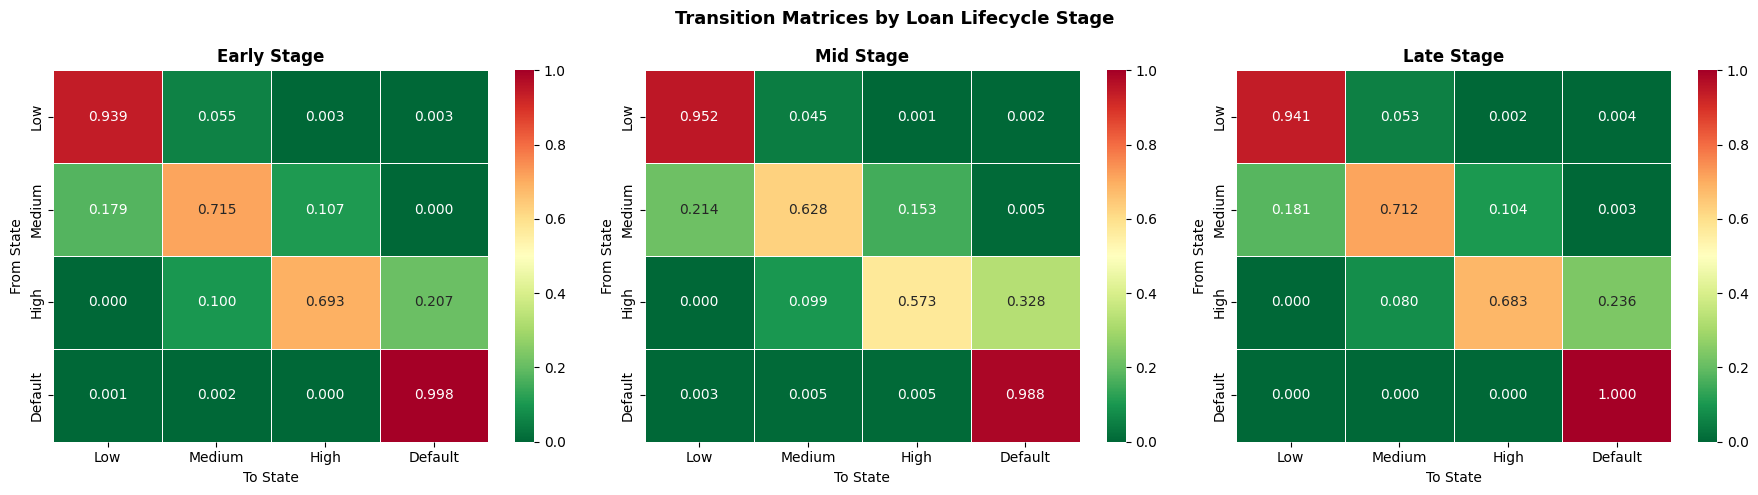

Chart saved.


In [4]:
# Visualise three matrices side by side
available_stages = list(stage_matrices.keys())
n = len(available_stages)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for ax, stage in zip(axes, available_stages):
        sns.heatmap(stage_matrices[stage], annot=True, fmt='.3f',
                    cmap='RdYlGn_r', vmin=0, vmax=1, linewidths=0.5, ax=ax,
                    annot_kws={'size': 10})
        ax.set_title(f'{stage}', fontsize=12, fontweight='bold')
        ax.set_xlabel('To State', fontsize=10)
        ax.set_ylabel('From State', fontsize=10)
    plt.suptitle('Transition Matrices by Loan Lifecycle Stage', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_lifecycle_transition_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved.')

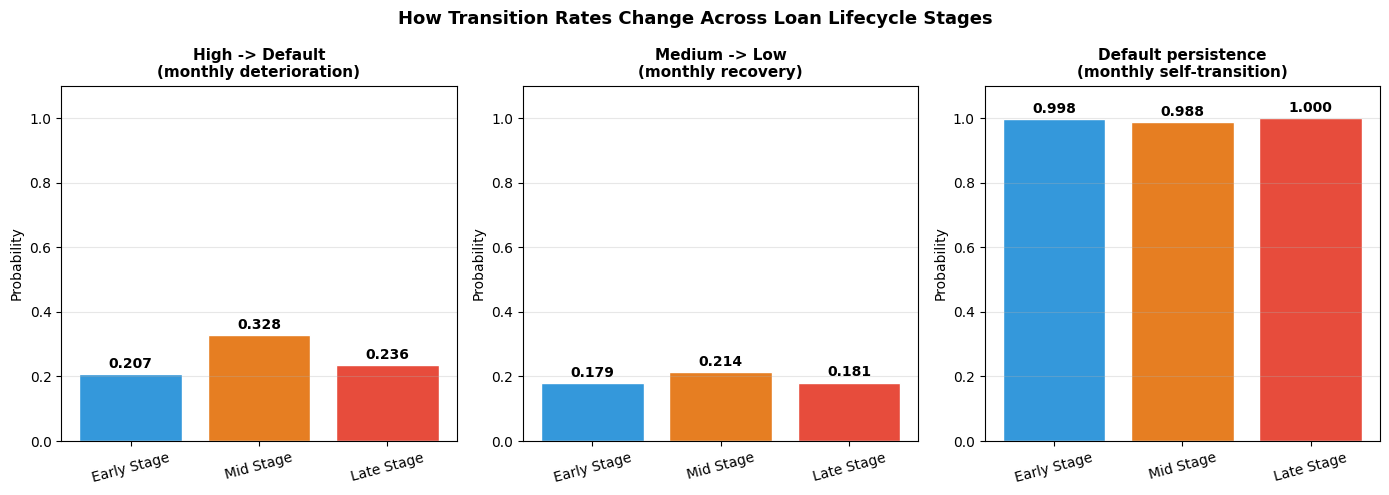

Comparison chart saved.


In [5]:
# Bar chart comparison of key rates
available_stages = list(stage_matrices.keys())
if len(available_stages) >= 2:
    metrics = {
        'High -> Default\n(monthly deterioration)': [stage_matrices[s].loc['High','Default'] for s in available_stages],
        'Medium -> Low\n(monthly recovery)': [stage_matrices[s].loc['Medium','Low'] for s in available_stages],
        'Default persistence\n(monthly self-transition)': [stage_matrices[s].loc['Default','Default'] for s in available_stages],
    }
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    colors = ['#3498db', '#e67e22', '#e74c3c']
    for ax, (metric, values) in zip(axes, metrics.items()):
        bars = ax.bar(available_stages, values, color=colors[:len(available_stages)], edgecolor='white')
        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability')
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', rotation=15)
    plt.suptitle('How Transition Rates Change Across Loan Lifecycle Stages', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_lifecycle_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Comparison chart saved.')

In [6]:
# Summary findings
print('=' * 60)
print('LIFECYCLE STAGE ANALYSIS — KEY FINDINGS')
print('=' * 60)
available_stages = list(stage_matrices.keys())
if len(available_stages) >= 2:
    print('\nHigh -> Default probability by lifecycle stage:')
    high_to_default = []
    for stage in available_stages:
        prob = stage_matrices[stage].loc['High', 'Default']
        high_to_default.append(prob)
        print(f'  {stage:<15}: {prob:.4f} ({prob*100:.1f}%)')

    diff = max(high_to_default) - min(high_to_default)
    print(f'\nDifference across stages: {diff*100:.1f} percentage points')

    if diff > 0.05:
        print('\nFINDING: Lifecycle stage significantly affects transition probabilities.')
        print('The Markov property assumption is partially violated.')
        print('Loan age matters — late-stage loans behave differently from early-stage.')
        print('This supports using lifecycle-aware matrices for portfolio forecasting.')
    else:
        print('\nFINDING: Lifecycle stage has minimal effect on transition probabilities.')
        print('The standard Markov assumption holds well for this portfolio.')

    print('\nMedium -> Low recovery rate by lifecycle stage:')
    for stage in available_stages:
        prob = stage_matrices[stage].loc['Medium', 'Low']
        print(f'  {stage:<15}: {prob:.4f} ({prob*100:.1f}%)')

# Save
for stage in available_stages:
    safe = stage.replace(' ', '_').upper()
    stage_matrices[stage].to_csv(f'bk_transition_{safe}.csv')
    print(f'Saved bk_transition_{safe}.csv')

LIFECYCLE STAGE ANALYSIS — KEY FINDINGS

High -> Default probability by lifecycle stage:
  Early Stage    : 0.2075 (20.7%)
  Mid Stage      : 0.3284 (32.8%)
  Late Stage     : 0.2363 (23.6%)

Difference across stages: 12.1 percentage points

FINDING: Lifecycle stage significantly affects transition probabilities.
The Markov property assumption is partially violated.
Loan age matters — late-stage loans behave differently from early-stage.
This supports using lifecycle-aware matrices for portfolio forecasting.

Medium -> Low recovery rate by lifecycle stage:
  Early Stage    : 0.1785 (17.9%)
  Mid Stage      : 0.2139 (21.4%)
  Late Stage     : 0.1808 (18.1%)
Saved bk_transition_EARLY_STAGE.csv
Saved bk_transition_MID_STAGE.csv
Saved bk_transition_LATE_STAGE.csv
